# A vertical-sequence RNN emulator for ClimSim

ClimSim ([LEAP Center](https://leap.columbia.edu), [dataset paper](https://arxiv.org/abs/2306.08754)) is a large hybrid ML-physics dataset for climate modeling: given one atmospheric column's state, predict the sub-grid physics tendencies a high-resolution simulation would produce. This notebook builds a small RNN emulator for it and evaluates it against ClimSim's own constant-prediction and linear-regression baselines.

**Design note.** An earlier version of this notebook (kept in `archive/legacy_quickstart_RNN_original.ipynb` for comparison) treated each *day* as a single training example: 72 timesteps as the sequence axis, and all 384 grid columns x 60 levels flattened into one 47,616-dimensional feature vector per timestep. That gives exactly 2 training examples (one per day) and no clear physical reason for that particular sequence axis.

ClimSim's own baseline instead predicts one grid column at a time, and there *is* a natural sequence axis within a column: the 60 vertical levels, which are physically coupled by convection and vertical mixing. This notebook uses that framing: each `(timestep, column)` pair is one sample, and the RNN reads down the column level by level. That turns 2 days of data into ~55k samples instead of 2.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

from climsim_rnn import (
    LEVEL_TARGET_VARS,
    SCALAR_TARGET_VARS,
    Normalizer,
    build_model,
    build_samples,
    evaluate,
    load_day,
)

RAW_DIR = Path("../data/raw")
FIG_DIR = Path("../results/figures")
METRICS_DIR = Path("../results/metrics")
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load and reshape

Day 1 supplies the training/validation split; day 2 is held out entirely and used only for final evaluation, so the reported metrics reflect generalization to an unseen day rather than an unseen random subset of the same day.

In [2]:
ds_in_day1, ds_out_day1 = load_day(RAW_DIR, "day1")
ds_in_day2, ds_out_day2 = load_day(RAW_DIR, "day2")
print("day1 grid:", dict(ds_in_day1.sizes))
print("day2 grid:", dict(ds_in_day2.sizes))

day1 grid: {'time': 72, 'ncol': 384, 'lev': 60}
day2 grid: {'time': 72, 'ncol': 384, 'lev': 60}


In [3]:
day1_samples = build_samples(ds_in_day1, ds_out_day1)
day2_samples = build_samples(ds_in_day2, ds_out_day2)

print("day1 samples:", day1_samples.level_features.shape[0])
print("day2 samples (held-out test):", day2_samples.level_features.shape[0])

day1 samples: 27648
day2 samples (held-out test): 27648


In [4]:
train_idx, val_idx = train_test_split(
    np.arange(day1_samples.level_features.shape[0]), test_size=0.1, random_state=SEED
)

from dataclasses import replace

train_samples = replace(
    day1_samples,
    level_features=day1_samples.level_features[train_idx],
    aux_features=day1_samples.aux_features[train_idx],
    level_targets=day1_samples.level_targets[train_idx],
    scalar_targets=day1_samples.scalar_targets[train_idx],
)
val_samples = replace(
    day1_samples,
    level_features=day1_samples.level_features[val_idx],
    aux_features=day1_samples.aux_features[val_idx],
    level_targets=day1_samples.level_targets[val_idx],
    scalar_targets=day1_samples.scalar_targets[val_idx],
)
print("train:", train_samples.level_features.shape[0], "val:", val_samples.level_features.shape[0])

train: 24883 val: 2765


## Normalize

Statistics are fit on the training split only, then applied to validation and the held-out day 2 test set -- fitting on anything but train would leak information about data the model is later evaluated on.

In [5]:
normalizer = Normalizer()
train_n = normalizer.fit_transform(train_samples)
val_n = normalizer.transform(val_samples)
test_n = normalizer.transform(day2_samples)

for name, batch in [("train", train_n), ("val", val_n), ("test", test_n)]:
    arrays = [batch.level_features, batch.aux_features, batch.level_targets, batch.scalar_targets]
    assert all(np.isfinite(a).all() for a in arrays), f"non-finite values in {name}"
print("all splits finite after normalization")

all splits finite after normalization


## Model

In [6]:
model = build_model(
    levels=train_samples.level_features.shape[1],
    level_input_features=train_samples.level_features.shape[2],
    aux_input_features=train_samples.aux_features.shape[1],
    level_target_features=train_samples.level_targets.shape[2],
    scalar_target_features=train_samples.scalar_targets.shape[1],
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ surface_aux         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ level_sequence      │ (None, 60, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 60, 4)     │          0 │ surface_aux[0][0] │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 60, 6)     │          0 │ level_sequence[0… │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 60, 64)    │     18,176 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 60, 64),  │     33,024 │ lstm[0][0]        │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 68)        │          0 │ lstm_1[0][1],     │
│ (Concatenate)       │                   │            │ surface_aux[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,208 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ level_tendencies    │ (None, 60, 2)     │        130 │ lstm_1[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ surface_fluxes      │ (None, 8)         │        264 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 53,802 (210.16 KB)

 Trainable params: 53,802 (210.16 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history = model.fit(
    [train_n.level_features, train_n.aux_features],
    [train_n.level_targets, train_n.scalar_targets],
    validation_data=(
        [val_n.level_features, val_n.aux_features],
        [val_n.level_targets, val_n.scalar_targets],
    ),
    epochs=40,
    batch_size=256,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/40


98/98 - 12s - 127ms/step - level_tendencies_loss: 0.6213 - loss: 1.0209 - surface_fluxes_loss: 0.3964 - val_level_tendencies_loss: 0.5782 - val_loss: 0.8297 - val_surface_fluxes_loss: 0.2548


Epoch 2/40


98/98 - 10s - 102ms/step - level_tendencies_loss: 0.5320 - loss: 0.7387 - surface_fluxes_loss: 0.2053 - val_level_tendencies_loss: 0.5377 - val_loss: 0.7350 - val_surface_fluxes_loss: 0.2006


Epoch 3/40


...

98/98 - 12s - 120ms/step - level_tendencies_loss: 0.3648 - loss: 0.4172 - surface_fluxes_loss: 0.0515 - val_level_tendencies_loss: 0.3970 - val_loss: 0.4548 - val_surface_fluxes_loss: 0.0606


Epoch 39/40


98/98 - 12s - 123ms/step - level_tendencies_loss: 0.3638 - loss: 0.4160 - surface_fluxes_loss: 0.0513 - val_level_tendencies_loss: 0.3958 - val_loss: 0.4535 - val_surface_fluxes_loss: 0.0606


Epoch 40/40


98/98 - 11s - 114ms/step - level_tendencies_loss: 0.3619 - loss: 0.4133 - surface_fluxes_loss: 0.0505 - val_level_tendencies_loss: 0.3929 - val_loss: 0.4491 - val_surface_fluxes_loss: 0.0590


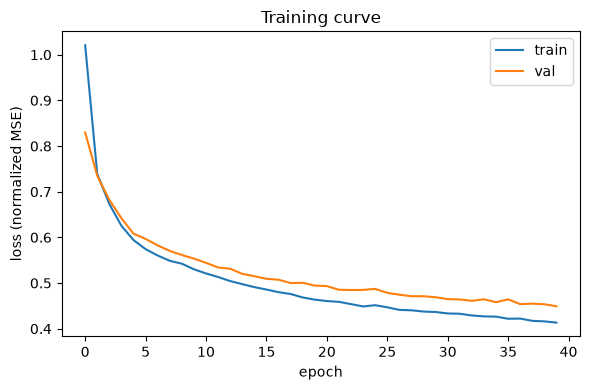

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history.history["loss"], label="train")
ax.plot(history.history["val_loss"], label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (normalized MSE)")
ax.set_title("Training curve")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "training_loss.png", dpi=150)
plt.show()

## Evaluate on the held-out day

Metrics are reported in physical units (K/s, kg/kg/s, W/m^2) after inverting the normalization, pooling over all levels and samples for the two level variables and over samples for the eight scalar surface variables -- the same grouping ClimSim's own baseline evaluation uses (see `archive/*_data.csv`), so the two are directly comparable.

In [9]:
pred_level_n, pred_scalar_n = model.predict(
    [test_n.level_features, test_n.aux_features], batch_size=512, verbose=0
)
pred_level = normalizer.inverse_transform_level_targets(pred_level_n)
pred_scalar = normalizer.inverse_transform_scalar_targets(pred_scalar_n)

metrics_df = evaluate(day2_samples.level_targets, pred_level, day2_samples.scalar_targets, pred_scalar)
metrics_df.to_csv(METRICS_DIR / "rnn_emulator_metrics.csv", index=False)
metrics_df

,variable,mae,rmse,r2,bias
0,dT/dt,1.733651e-05,3.506687e-05,0.578752,1.014668e-07
1,dq/dt,1.024282e-08,2.829128e-08,0.149849,-3.701489e-11
2,cam_out_NETSW,3.005714e+01,5.210607e+01,0.958919,4.733183e-01
3,cam_out_FLWDS,9.375422e+00,1.289115e+01,0.972327,-3.432062e-01
4,cam_out_PRECSC,2.112199e-09,5.365283e-09,0.602004,-5.340252e-10
5,cam_out_PRECC,1.999708e-08,5.234237e-08,0.667555,-1.313460e-09
6,cam_out_SOLS,1.605489e+01,3.035550e+01,0.928985,3.108858e-01
7,cam_out_SOLL,1.868916e+01,3.511044e+01,0.915862,3.189074e-01
8,cam_out_SOLSD,8.426414e+00,1.514872e+01,0.896957,-2.347195e-01
9,cam_out_SOLLD,7.594686e+00,1.448365e+01,0.767490,1.942835e-01


## Comparison against ClimSim's constant and linear-regression baselines

`archive/*_data.csv` holds MAE/RMSE/R2/bias for ClimSim's constant-prediction (`const`) and multiple linear regression (`mlr`) baselines, computed with ClimSim's official evaluation pipeline on ClimSim's own (much larger) scoring data split. Two caveats on comparing against them directly:

- The 8 scalar surface variables (NETSW, FLWDS, PRECSC, PRECC, SOLS, SOLL, SOLSD, SOLLD) are already in shared, unweighted physical units in both this notebook and the baseline, so MAE/RMSE are directly comparable there.
- `dT/dt` and `dq/dt` are **not** directly comparable: ClimSim's official pipeline reports these after an energy-unit weighting (by pressure-level thickness and grid-cell area, converted to W/m^2), while this notebook reports them in raw K/s and kg/kg/s. The five-orders-of-magnitude gap below is a unit difference, not a 100,000x accuracy improvement -- treat R2 as the meaningful cross-check for those two rows instead, since R2 is scale-invariant.

In [10]:
ARCHIVE_DIR = Path("../archive")

name_map = {
    "$dT/dt$": "dT/dt",
    "$dq/dt$": "dq/dt",
    **{v.removeprefix("cam_out_"): v for v in SCALAR_TARGET_VARS},
}

def load_baseline(metric):
    df = pd.read_csv(ARCHIVE_DIR / f"{metric}_data.csv")
    df["variable"] = df["variable"].replace(name_map)
    return df.set_index("variable")[["const", "mlr"]].rename(
        columns={"const": f"{metric}_const", "mlr": f"{metric}_mlr"}
    )

baseline = pd.concat([load_baseline(m) for m in ["MAE", "RMSE", "R2", "bias"]], axis=1)
comparison = metrics_df.set_index("variable").join(baseline, how="left")
comparison[["mae", "MAE_const", "MAE_mlr", "rmse", "RMSE_const", "RMSE_mlr"]]

,mae,MAE_const,MAE_mlr,rmse,RMSE_const,RMSE_mlr
variable,,,,,,
dT/dt,1.733651e-05,4.583962,4.011654,3.506687e-05,6.929862,6.038868
dq/dt,1.024282e-08,5.819820,5.714436,2.829128e-08,9.231061,8.742977
cam_out_NETSW,3.005714e+01,195.800764,63.026779,5.210607e+01,239.098699,87.843474
cam_out_FLWDS,9.375422e+00,58.443026,12.332524,1.289115e+01,65.343607,14.885521
cam_out_PRECSC,2.112199e-09,10.648787,7.476294,5.365283e-09,14.266035,10.813780
cam_out_PRECC,1.999708e-08,97.279934,92.740549,5.234237e-08,162.411342,143.812581
cam_out_SOLS,1.605489e+01,83.094222,37.201246,3.035550e+01,105.521637,52.376446
cam_out_SOLL,1.868916e+01,89.019119,40.029796,3.511044e+01,112.065642,56.807899
cam_out_SOLSD,8.426414e+00,37.259576,12.795067,1.514872e+01,45.891535,20.368948


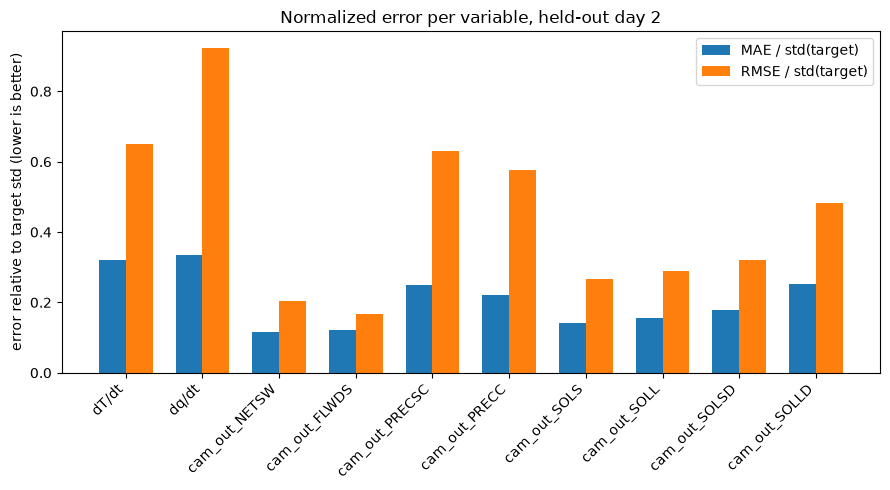

In [11]:
# Raw MAE/RMSE aren't comparable across variables here -- dT/dt is O(1e-5) K/s and NETSW is
# O(10) W/m^2, so a shared linear axis makes most bars invisible. Normalizing by each
# variable's own standard deviation (on the same held-out day) gives a scale-free "fraction
# of natural variability explained" that's comparable across variables and equivalent to 1 - R2.
target_std = np.concatenate(
    [day2_samples.level_targets.std(axis=(0, 1)), day2_samples.scalar_targets.std(axis=0)]
)
nmae = metrics_df["mae"].to_numpy() / target_std
nrmse = metrics_df["rmse"].to_numpy() / target_std

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics_df))
width = 0.35
ax.bar(x - width / 2, nmae, width=width, label="MAE / std(target)")
ax.bar(x + width / 2, nrmse, width=width, label="RMSE / std(target)")
ax.set_xticks(x, metrics_df["variable"], rotation=45, ha="right")
ax.set_ylabel("error relative to target std (lower is better)")
ax.set_title("Normalized error per variable, held-out day 2")
ax.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "normalized_error_per_variable.png", dpi=150)
plt.show()

## Limitations and next steps

- **Two days of data.** Training uses one day (~25k column-timesteps after the train/val split), tested on a single held-out day. ClimSim's full dataset spans years; results here show the approach works, not that it's tuned or competitive at scale.
- **Minimal feature set.** Inputs are limited to temperature, humidity, surface pressure, and three surface fluxes -- the subset the original notebook used. ClimSim's full input specification also includes winds, ozone, additional moisture species, and more.
- **No energy-unit weighting.** ClimSim's official leaderboard weights tendencies by pressure-level thickness and grid-cell area to put every variable in a common energy unit before scoring. Metrics here are plain per-variable MAE/RMSE/R2/bias in each variable's native physical unit, which is enough to compare against the archived baselines' orders of magnitude but not to submit to ClimSim's leaderboard.
- **Architecture.** A 2-layer LSTM was a reasonable starting point given the vertical-sequence framing; it hasn't been tuned (units, depth, dropout, learning-rate schedule) or compared against non-recurrent alternatives (e.g. a plain MLP per level, or attention over levels).